In [10]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\user\Documents\E-COMMERCE_DATASETS_PROJECT
['eda_pynb.ipynb', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [12]:
import pandas as pd
import numpy as np

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

print("Orders shape:", orders.shape)
print("Order Items shape:", order_items.shape)
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Payments shape:", payments.shape)

Orders shape: (99441, 8)
Order Items shape: (112650, 7)
Customers shape: (99441, 5)
Products shape: (32951, 9)
Payments shape: (103886, 5)


In [13]:
print("=== ORDERS ===")
print(orders.info())
print(orders.isnull().sum())
print()

print("=== ORDER ITEMS ===")
print(order_items.info())
print(order_items.isnull().sum())

=== ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivere

In [14]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [16]:
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

print(orders['delivery_delay_days'].describe())

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [18]:
late_orders = orders[orders['delivery_delay_days'] > 0]
print("Total Late Orders:", len(late_orders))
print("Percentage Late:", round(len(late_orders) / len(orders.dropna(subset=['delivery_delay_days'])) * 100, 2), "%")
print()
print(late_orders['delivery_delay_days'].describe())

Total Late Orders: 6535
Percentage Late: 6.77 %

count    6535.000000
mean       10.620352
std        14.643844
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_delay_days, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_20204\2896693193.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='delivery_status', palette=['#D85A30','#639922','#888780'])


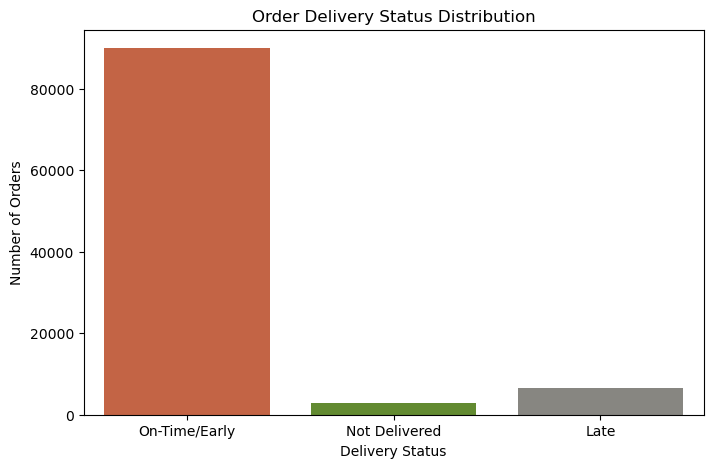

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

orders['delivery_status'] = orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On-Time/Early' if pd.notna(x) else 'Not Delivered'
)

plt.figure(figsize=(8,5))
sns.countplot(data=orders, x='delivery_status', palette=['#D85A30','#639922','#888780'])
plt.title('Order Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.show()

In [21]:
print("=== CUSTOMERS ===")
print(customers.info())
print(customers.isnull().sum())
print()

print("=== PRODUCTS ===")
print(products.info())
print(products.isnull().sum())
print()

print("=== PAYMENTS ===")
print(payments.info())
print(payments.isnull().sum())

=== CUSTOMERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

=== PRODUCTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951

In [22]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [23]:
products = products.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

In [25]:
print(products.isnull().sum())
print("New shape:", products.shape)

product_id                      0
product_category_name           0
product_name_lenght           609
product_description_lenght    609
product_photos_qty            609
product_weight_g                0
product_length_cm               0
product_height_cm               0
product_width_cm                0
dtype: int64
New shape: (32949, 9)


In [27]:
products = products.drop(columns=['product_name_lenght', 'product_description_lenght', 'product_photos_qty'])

print(products.isnull().sum())
print("Final shape:", products.shape)

product_id               0
product_category_name    0
product_weight_g         0
product_length_cm        0
product_height_cm        0
product_width_cm         0
dtype: int64
Final shape: (32949, 6)


In [29]:
orders.to_csv('orders_cleaned.csv', index=False)
order_items.to_csv('order_items_cleaned.csv', index=False)
customers.to_csv('customers_cleaned.csv', index=False)
products.to_csv('products_cleaned.csv', index=False)
payments.to_csv('payments_cleaned.csv', index=False)

print("All files saved successfully!")

All files saved successfully!


# exploratory data analysis(EDA)

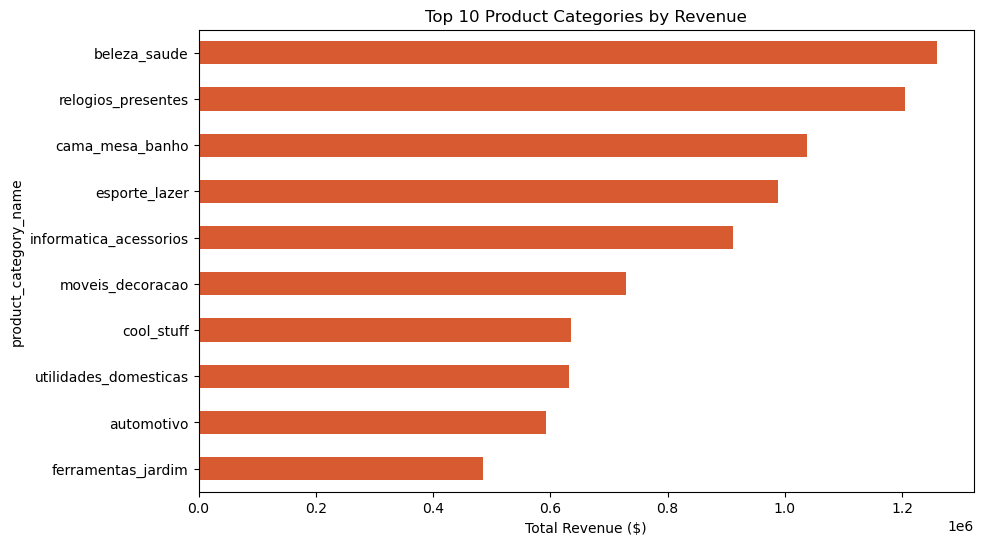

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

category_revenue = order_items.merge(products, on='product_id') \
    .groupby('product_category_name')['price'].sum() \
    .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
category_revenue.plot(kind='barh', color='#D85A30')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue ($)')
plt.gca().invert_yaxis()
plt.show()

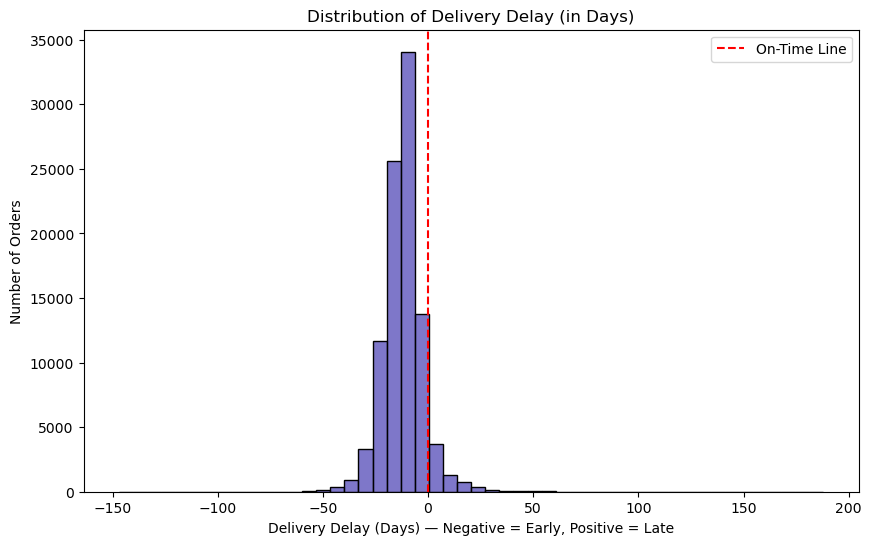

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(orders['delivery_delay_days'].dropna(), bins=50, color='#534AB7')
plt.title('Distribution of Delivery Delay (in Days)')
plt.xlabel('Delivery Delay (Days) — Negative = Early, Positive = Late')
plt.ylabel('Number of Orders')
plt.axvline(x=0, color='red', linestyle='--', label='On-Time Line')
plt.legend()
plt.show()

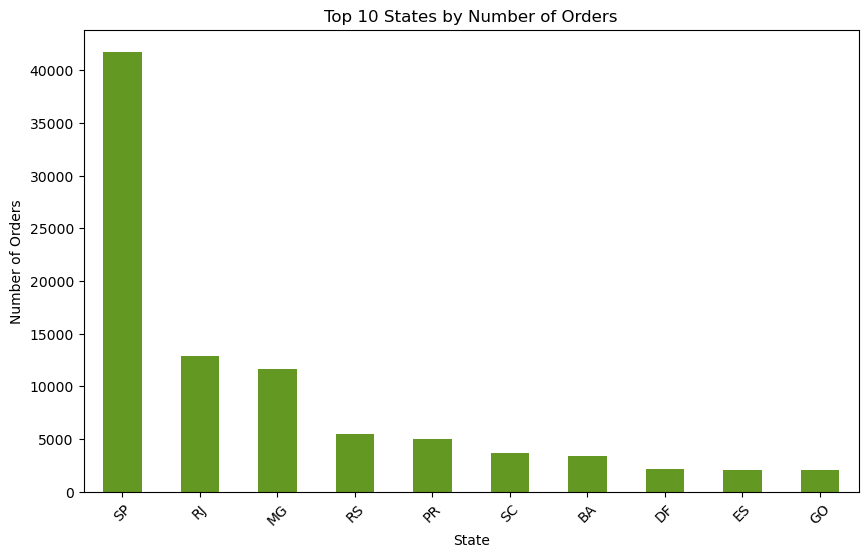

In [32]:
state_orders = customers['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,6))
state_orders.plot(kind='bar', color='#639922')
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

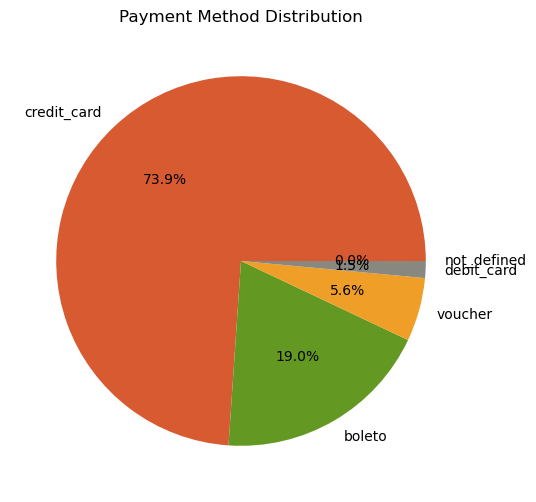

In [33]:
plt.figure(figsize=(8,6))
payments['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                               colors=['#D85A30','#639922','#EF9F27','#888780','#534AB7'])
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

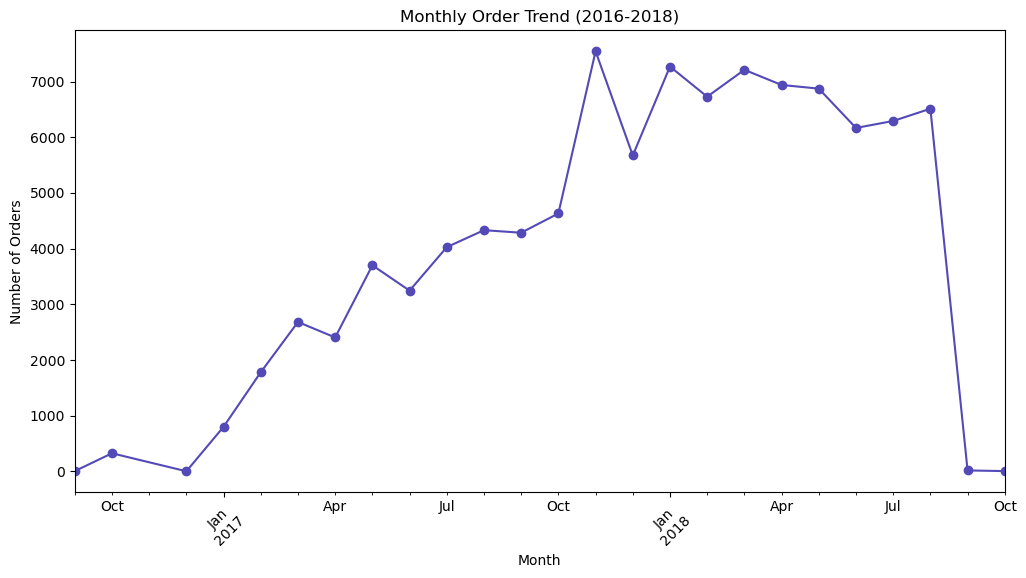

In [34]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_trend = orders.groupby('order_month').size()

plt.figure(figsize=(12,6))
monthly_trend.plot(kind='line', marker='o', color='#534AB7')
plt.title('Monthly Order Trend (2016-2018)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()